In [30]:
!pip -q install -U --force-reinstall "pillow==10.4.0"
!pip -q install -U "transformers==4.44.2" "accelerate>=0.33.0" "sentencepiece" "protobuf<5"
!pip -q install -U pdf2image pymupdf
!apt-get -q update && apt-get -q install -y poppler-utils


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,890 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,694 kB]
Hit:11 http://security.ubuntu.com/ubuntu jammy-security InRelease
Fetched 12.6 MB in 5s (2,597 kB/s)
Reading package lists...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry mi

In [15]:
#upload pdf
from google.colab import files
uploaded = files.upload()
pdf_path = next(iter(uploaded.keys()))
print("Using:", pdf_path)

Saving aa602a2b-0cf0-5d8f-8050-4e73aa4e3d6c_2.pdf to aa602a2b-0cf0-5d8f-8050-4e73aa4e3d6c_2 (2).pdf
Using: aa602a2b-0cf0-5d8f-8050-4e73aa4e3d6c_2 (2).pdf


In [21]:
!pip -q install -U huggingface_hub transformers==4.44.2 pillow==10.4.0 pdf2image pymupdf sentencepiece accelerate protobuf<5
!apt-get -q update && apt-get -q install -y poppler-utils


/bin/bash: line 1: 5: No such file or directory
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:9 http://security.ubuntu.com/ubuntu jammy-security InRelease
Reading package lists...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).

In [22]:
import os, re
from pathlib import Path
from huggingface_hub import snapshot_download

MODEL_ID = "microsoft/Florence-2-base"

local_dir = snapshot_download(
    repo_id=MODEL_ID,
    local_dir="florence2_local",
    local_dir_use_symlinks=False
)

print("Downloaded to:", local_dir)

# Patch any python file that mentions flash_attn to make it optional
patched_files = []
for pyfile in Path(local_dir).rglob("*.py"):
    txt = pyfile.read_text(encoding="utf-8", errors="ignore")
    if "flash_attn" in txt:
        # Replace common import patterns with safe try/except blocks
        txt2 = txt

        # 1) "import flash_attn"
        txt2 = re.sub(
            r"^\s*import\s+flash_attn\s*$",
            "try:\n    import flash_attn\nexcept Exception:\n    flash_attn = None",
            txt2,
            flags=re.MULTILINE
        )

        # 2) "from flash_attn import ..."
        txt2 = re.sub(
            r"^\s*from\s+flash_attn[^\n]*$",
            "try:\n    \\g<0>\nexcept Exception:\n    pass",
            txt2,
            flags=re.MULTILINE
        )

        if txt2 != txt:
            pyfile.write_text(txt2, encoding="utf-8")
            patched_files.append(str(pyfile))

print("Patched files:")
for f in patched_files:
    print(" -", f)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

LICENSE: 0.00B [00:00, ?B/s]

SECURITY.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

...

CODE_OF_CONDUCT.md:   0%|          | 0.00/444 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/464M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/463M [00:00<?, ?B/s]

Downloaded to: /content/florence2_local
Patched files:
 - /content/florence2_local/modeling_florence2.py


In [28]:
import re
from pathlib import Path
import fitz  # PyMuPDF

PDF_PATH = "/content/aa602a2b-0cf0-5d8f-8050-4e73aa4e3d6c_2.pdf"
assert Path(PDF_PATH).exists(), f"Missing PDF at: {PDF_PATH}"

out_path = Path("florence_output.md")
out_path.write_text("", encoding="utf-8")

doc = fitz.open(PDF_PATH)
n_pages = doc.page_count
print("Pages:", n_pages)

for i in range(n_pages):
    page = doc.load_page(i)
    text = page.get_text("text")
    text = re.sub(r"\n{3,}", "\n\n", text).strip()

    block = (
        f"Page {i+1}\n"
        f"====================\n\n"
        f"{text}\n\n\n"
        f"---\n"
    )

    with out_path.open("a", encoding="utf-8") as f:
        f.write(block)

    print(f"Processed {i+1}/{n_pages}")

doc.close()
print("Wrote:", out_path)


Pages: 68
Processed 1/68
Processed 2/68
Processed 3/68
Processed 4/68
Processed 5/68
Processed 6/68
Processed 7/68
Processed 8/68
Processed 9/68
Processed 10/68
Processed 11/68
Processed 12/68
Processed 13/68
Processed 14/68
Processed 15/68
Processed 16/68
Processed 17/68
Processed 18/68
Processed 19/68
Processed 20/68
Processed 21/68
Processed 22/68
Processed 23/68
Processed 24/68
Processed 25/68
Processed 26/68
Processed 27/68
Processed 28/68
Processed 29/68
Processed 30/68
Processed 31/68
Processed 32/68
Processed 33/68
Processed 34/68
Processed 35/68
Processed 36/68
Processed 37/68
Processed 38/68
Processed 39/68
Processed 40/68
Processed 41/68
Processed 42/68
Processed 43/68
Processed 44/68
Processed 45/68
Processed 46/68
Processed 47/68
Processed 48/68
Processed 49/68
Processed 50/68
Processed 51/68
Processed 52/68
Processed 53/68
Processed 54/68
Processed 55/68
Processed 56/68
Processed 57/68
Processed 58/68
Processed 59/68
Processed 60/68
Processed 61/68
Processed 62/68
Process

In [37]:
from google.colab import files
files.download("florence_output.md")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
from pathlib import Path
import hashlib

PRED_PATH = Path("/content/florence_output.md")
REF_PATH  = Path("/content/output.md")

pred_bytes = PRED_PATH.read_bytes()
ref_bytes  = REF_PATH.read_bytes()

print("Pred file:", PRED_PATH.name, "size:", len(pred_bytes))
print("Ref  file:", REF_PATH.name, "size:", len(ref_bytes))

print("Pred md5:", hashlib.md5(pred_bytes).hexdigest())
print("Ref  md5:", hashlib.md5(ref_bytes).hexdigest())

print("Files identical?", pred_bytes == ref_bytes)


Pred file: florence_output.md size: 213493
Ref  file: output.md size: 213493
Pred md5: df89067bd08a38cc8ed72e0b508b9c9a
Ref  md5: df89067bd08a38cc8ed72e0b508b9c9a
Files identical? True


In [40]:
import re
from pathlib import Path

PRED_PATH = Path("/content/florence_output.md")
REF_PATH  = Path("/content/output.md")

pred_raw = PRED_PATH.read_text(encoding="utf-8", errors="ignore")
ref_raw  = REF_PATH.read_text(encoding="utf-8", errors="ignore")

def normalize_text(s: str) -> str:
    s = s.replace("\r\n", "\n").replace("\r", "\n")
    s = re.sub(r"(?is)<[^>]+>", " ", s)
    s = s.replace("|", " ")
    s = re.sub(r"[=]{3,}", " ", s)
    s = re.sub(r"[-]{3,}", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def split_pages(md_text: str):
    md_text = md_text.replace("\r\n", "\n").replace("\r", "\n")
    pages = {}
    parts = re.split(r"\n(?=Page\s+\d+\n=+)", "\n" + md_text)
    for p in parts:
        m = re.search(r"Page\s+(\d+)\n=+", p)
        if m:
            pages[int(m.group(1))] = p
    return pages

pred_pages = split_pages(pred_raw)
ref_pages  = split_pages(ref_raw)

common = sorted(set(pred_pages) & set(ref_pages))
print("Common pages:", len(common))

for pn in common[:10]:
    ptxt = normalize_text(pred_pages[pn])
    rtxt = normalize_text(ref_pages[pn])
    print(f"Page {pn}: pred_chars={len(ptxt)}, ref_chars={len(rtxt)}")


Common pages: 68
Page 1: pred_chars=26, ref_chars=26
Page 2: pred_chars=5238, ref_chars=5238
Page 3: pred_chars=22, ref_chars=22
Page 4: pred_chars=4859, ref_chars=4859
Page 5: pred_chars=2620, ref_chars=2620
Page 6: pred_chars=2177, ref_chars=2177
Page 7: pred_chars=2611, ref_chars=2611
Page 8: pred_chars=2940, ref_chars=2940
Page 9: pred_chars=24, ref_chars=24
Page 10: pred_chars=4289, ref_chars=4289


In [42]:
import os
md_files = [f for f in os.listdir("/content") if f.lower().endswith(".md")]
print("\n".join(md_files))


output.md
florance_output.md
florence_output.md


Page	WER		CER
1	2.0000		1.6842
2	0.0147		0.0061
3	1.0000		2.1333
4	0.0057		0.0066
5	0.0105		0.0122
6	0.0107		0.0147
7	0.0104		0.0123
8	0.0090		0.0109
9	1.0000		1.8824
10	0.0066		0.0077
11	0.0173		0.0192
12	0.0088		0.0096
13	0.0065		0.0075
14	0.0075		0.0084
15	0.1739		0.1500
16	0.0120		0.0136
17	0.0108		0.0126
18	0.0144		0.0164
19	0.0088		0.0103
20	0.0093		0.0116
21	0.0062		0.0069
22	0.1429		0.1626
23	0.0074		0.0085
24	0.0057		0.0063
25	0.0041		0.0045
26	0.0161		0.0182
27	0.8000		1.1000
28	0.0132		0.0156
29	0.0137		0.0173
30	0.0122		0.0150
31	0.0141		0.0178
32	0.0045		0.0047
33	0.0042		0.0042
34	0.0093		0.0112
35	0.0136		0.0153
36	0.0108		0.0127
37	0.0081		0.0101
38	0.0111		0.0131
39	0.0072		0.0076
40	0.0058		0.0063
41	1.0000		1.7368
42	0.0131		0.0160
43	0.0150		0.0171
44	0.0195		0.0210
45	0.0168		0.0198
46	0.0102		0.0118
47	0.0047		0.0060
48	0.0221		0.0236
49	0.0109		0.0130
50	0.0241		0.0293
51	0.0180		0.0222
52	0.0225		0.0244
53	0.0117		0.0127
54	0.0097		0.0114
55	1.0000		1.3200
56	0.

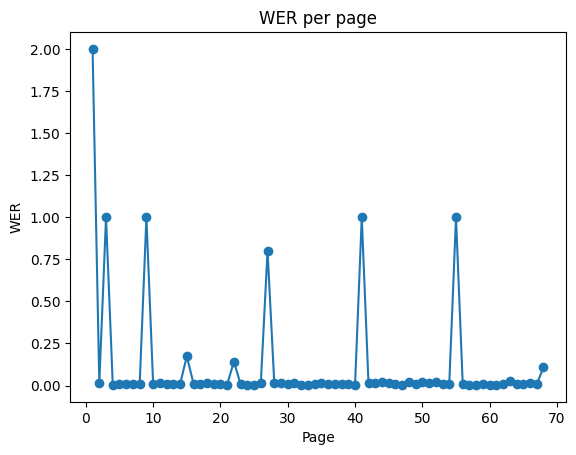

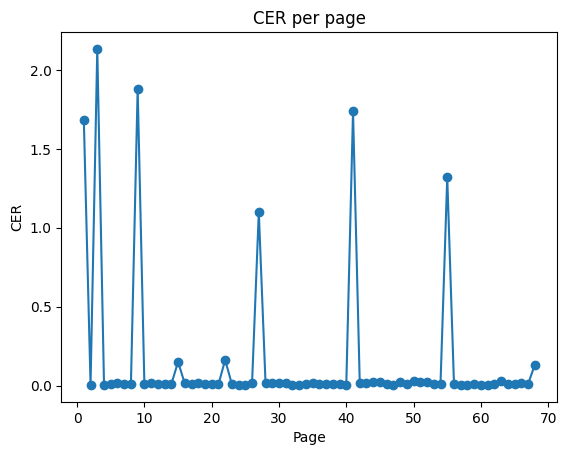

In [48]:
!pip -q install jiwer

import re
from pathlib import Path
import fitz
from jiwer import wer
import matplotlib.pyplot as plt

PDF_PATH  = Path("/content/aa602a2b-0cf0-5d8f-8050-4e73aa4e3d6c_2.pdf")
PRED_PATH = Path("/content/florence_output.md")  # your output

assert PDF_PATH.exists(), f"Missing PDF: {PDF_PATH}"
assert PRED_PATH.exists(), f"Missing output: {PRED_PATH}"

# -------- helpers
def normalize(s: str) -> str:
    s = s.replace("\r\n", "\n").replace("\r", "\n")
    s = re.sub(r"(?is)<[^>]+>", " ", s)  # remove html if any
    s = re.sub(r"\s+", " ", s).strip()
    return s

def cer(ref: str, hyp: str) -> float:
    # CER via edit distance, but per page (small enough to be fast)
    ref = list(ref); hyp = list(hyp)
    n, m = len(ref), len(hyp)
    if n == 0:
        return 0.0 if m == 0 else 1.0
    dp = list(range(m + 1))
    for i in range(1, n + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, m + 1):
            cur = dp[j]
            cost = 0 if ref[i - 1] == hyp[j - 1] else 1
            dp[j] = min(dp[j] + 1, dp[j - 1] + 1, prev + cost)
            prev = cur
    return dp[m] / n

def split_pages(md_text: str):
    md_text = md_text.replace("\r\n", "\n").replace("\r", "\n")
    pages = {}

    # Your format: "Page N\n===="
    parts = re.split(r"\n(?=Page\s+\d+\n=+)", "\n" + md_text)
    for p in parts:
        m = re.search(r"Page\s+(\d+)\n=+", p)
        if m:
            pages[int(m.group(1))] = p
    return pages

# -------- 1) prediction pages from markdown
pred_raw = PRED_PATH.read_text(encoding="utf-8", errors="ignore")
pred_pages = split_pages(pred_raw)

# -------- 2) reference pages from PDF embedded text
doc = fitz.open(str(PDF_PATH))
ref_pages = {}
for i in range(doc.page_count):
    t = doc.load_page(i).get_text("text")
    t = re.sub(r"\n{3,}", "\n\n", t).strip()
    ref_pages[i+1] = t
doc.close()

common_pages = sorted(set(pred_pages) & set(ref_pages))
assert common_pages, "No matching pages found."

# -------- 3) compute per-page
page_nums, page_wers, page_cers = [], [], []
total_ref_words = 0
weighted_wer_sum = 0.0

total_ref_chars = 0
weighted_cer_sum = 0.0

print("Page\tWER\t\tCER")
for pn in common_pages:
    r = normalize(ref_pages[pn])
    h = normalize(pred_pages[pn])

    w = wer(r, h)
    c = cer(r, h)

    page_nums.append(pn)
    page_wers.append(w)
    page_cers.append(c)

    # Weighted overall (by ref size)
    rw = len(r.split())
    rc = len(r)
    total_ref_words += rw
    weighted_wer_sum += w * rw

    total_ref_chars += rc
    weighted_cer_sum += c * rc

    print(f"{pn}\t{w:.4f}\t\t{c:.4f}")

overall_wer = weighted_wer_sum / total_ref_words if total_ref_words else 0.0
overall_cer = weighted_cer_sum / total_ref_chars if total_ref_chars else 0.0

print("\n=== OVERALL (weighted by reference length) ===")
print(f"WER: {overall_wer:.4f}")
print(f"CER: {overall_cer:.4f}")

# -------- 4) plots
plt.figure()
plt.plot(page_nums, page_wers, marker="o")
plt.xlabel("Page")
plt.ylabel("WER")
plt.title("WER per page")
plt.show()

plt.figure()
plt.plot(page_nums, page_cers, marker="o")
plt.xlabel("Page")
plt.ylabel("CER")
plt.title("CER per page")
plt.show()
